In [4]:
!pip install fpdf

CSV File Created Successfully!

Student Data:

     Name  Marks
0   Rahul     85
1  Anjali     92
2   Kiran     78
3   Sneha     88
4   Arjun     95

Average Marks: 87.6
Highest Marks: 95
Lowest Marks: 78


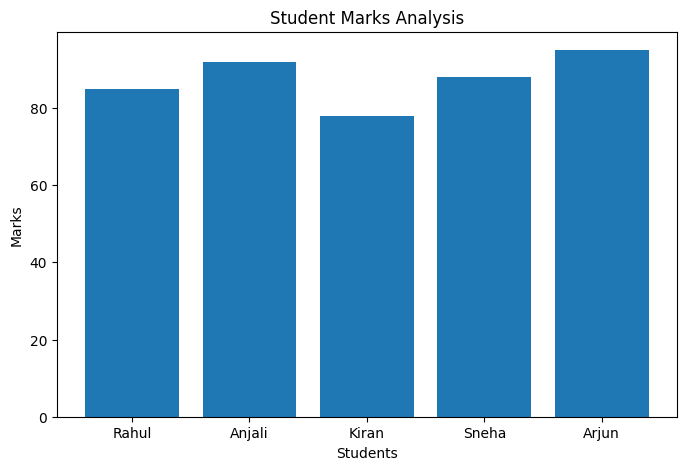


Chart Image Created Successfully!

PDF Report Generated Successfully!
Files Created:
1. student_data.csv
2. marks_chart.png
3. student_report.pdf


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from fpdf import FPDF

# ============================================================
# STEP 1 : CREATE SAMPLE DATA FILE
# ============================================================

data = {
    "Name": ["Rahul", "Anjali", "Kiran", "Sneha", "Arjun"],
    "Marks": [85, 92, 78, 88, 95]
}

df = pd.DataFrame(data)

# SAVE CSV FILE
df.to_csv("student_data.csv", index=False)

print("CSV File Created Successfully!")

# ============================================================
# STEP 2 : READ DATA FROM FILE
# ============================================================

df = pd.read_csv("student_data.csv")

print("\nStudent Data:\n")
print(df)

# ============================================================
# STEP 3 : DATA ANALYSIS
# ============================================================

average_marks = df["Marks"].mean()
highest_marks = df["Marks"].max()
lowest_marks = df["Marks"].min()

print("\nAverage Marks:", average_marks)
print("Highest Marks:", highest_marks)
print("Lowest Marks:", lowest_marks)

# ============================================================
# STEP 4 : CREATE VISUALIZATION
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(df["Name"], df["Marks"])

plt.title("Student Marks Analysis")
plt.xlabel("Students")
plt.ylabel("Marks")
plt.show()

# SAVE GRAPH IMAGE
plt.savefig("marks_chart.png")

plt.close()

print("\nChart Image Created Successfully!")

# ============================================================
# STEP 5 : GENERATE PDF REPORT
# ============================================================

pdf = FPDF()

pdf.add_page()

# TITLE

pdf.set_font("Arial", "B", 18)

pdf.cell(200, 10, "AUTOMATED REPORT GENERATION", ln=True, align='C')

pdf.ln(10)

# REPORT DETAILS

pdf.set_font("Arial", size=12)

pdf.cell(200, 10, "Student Performance Report", ln=True)

pdf.ln(5)

pdf.cell(200, 10, f"Average Marks : {average_marks}", ln=True)

pdf.cell(200, 10, f"Highest Marks : {highest_marks}", ln=True)

pdf.cell(200, 10, f"Lowest Marks : {lowest_marks}", ln=True)

pdf.ln(10)

# TABLE HEADER

pdf.set_font("Arial", "B", 12)

pdf.cell(80, 10, "Student Name", border=1)

pdf.cell(80, 10, "Marks", border=1)

pdf.ln()

# TABLE DATA

pdf.set_font("Arial", size=12)

for index, row in df.iterrows():

    pdf.cell(80, 10, row["Name"], border=1)

    pdf.cell(80, 10, str(row["Marks"]), border=1)

    pdf.ln()

pdf.ln(10)

# ADD CHART IMAGE

pdf.image("marks_chart.png", x=30, w=150)

# SAVE PDF

pdf.output("student_report.pdf")

# ============================================================
# FINAL MESSAGE
# ============================================================

print("\nPDF Report Generated Successfully!")
print("Files Created:")
print("1. student_data.csv")
print("2. marks_chart.png")
print("3. student_report.pdf")